# Imputación de Datos Hidrometeorológicos mediante Machine Learning



**Juan Sebastian Moreno Arteaga**

### Índice
1. Análisis exploratorio e identificación de valores faltantes
2. Selección y justificación de la metodología de ML
3. Construcción del modelo y generación de datos sintéticos
4. Validación del modelo con métricas de regresión
5. Documentación y conclusiones

---
## Preparación del entorno
Importamos las librerías necesarias.

In [81]:
# ============================================================
# Librerías principales (vistas en clase)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# scikit-learn: librería principal de ML usada en clase
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

print("Librerías importadas correctamente")

Librerías importadas correctamente


---
## 1. Análisis Exploratorio e Identificación de Valores Faltantes

In [82]:
# ============================================================
# 1.1  Carga del dataset desde CONAGUA
# ============================================================
import requests
url ='https://raw.githubusercontent.com/JuanMoreno003/txt/refs/heads/main/Conagua.txt'
response = requests.get(url)
contenido = response.text

In [83]:
import pandas as pd
data = pd.read_csv(url,encoding='latin1')
data

,COMISIÃN NACIONAL DEL AGUA
0,COORDINACIÃN GENERAL DEL SERVICIO METEOROLÃG...
1,BASE DE DATOS CLIMATOLÃGICA NACIONAL
2,REGISTRO DIARIO HISTÃRICO
3,EMISIÃN : 01/05/2026
4,DATOS DISPONIBLES EN LA BASE DE DATOS A: MAY D...
...,...
23809,2026-03-27\t0\t6.26\t34\t23
23810,2026-03-28\t0\t4.62\t35\t22
23811,2026-03-29\t0\t4.15\t34\t23
23812,2026-03-30\t0\t7.2\t36\t21.5


In [84]:
import pandas as pd
data = pd.read_csv(url, nrows=2,encoding='latin1')
data

,COMISIÃN NACIONAL DEL AGUA
0,COORDINACIÃN GENERAL DEL SERVICIO METEOROLÃG...
1,BASE DE DATOS CLIMATOLÃGICA NACIONAL


In [85]:
import pandas as pd
data = pd.read_csv(url, skiprows=3 ,nrows=13, header=None,encoding='latin1')
data

,0
0,REGISTRO DIARIO HISTÃRICO
1,EMISIÃN : 01/05/2026
2,DATOS DISPONIBLES EN LA BASE DE DATOS A: MAY D...
3,CON LA INFORMACIÃN SUMINISTRADA POR LAS UNIDA...
4,ESTACIÃN : 25015
5,NOMBRE : CULIACAN (DGE)
6,ESTADO : SINALOA
7,MUNICIPIO : CULIACÃN
8,SITUACIÃN : OPERANDO
9,CVE-OMM :


In [86]:
from numpy import array
import pandas as pd
c = pd.read_csv(url, skiprows=22,sep='\s+', nrows=1,encoding='latin1')
columns = [' '+c]
col =array(columns)
col

array([[[' (mm)', ' (mm)', ' (Â°C', ' )', ' (Â°C)']]], dtype=object)

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO

lines = contenido.splitlines()
for i, line in enumerate(lines):
    if "FECHA" in line and "PRECIP" in line:
        header_idx = i
        break


columns = ['FECHA', 'PRECIP', 'EVAP', 'TMAX', 'TMIN']

data = pd.read_csv(StringIO(contenido),
                   skiprows=header_idx + 2,
                   sep=r'\s+',
                   names=columns,
                   na_values=['Nulo'])

data['FECHA'] = pd.to_datetime(data['FECHA'])
cols_numericas = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']
for col in cols_numericas:
    data[col] = pd.to_numeric(data[col], errors='coerce')

df_raw=data
df_raw.head()

,FECHA,PRECIP,EVAP,TMAX,TMIN
0,1961-01-01,0.0,2.9,22.0,10.5
1,1961-01-02,0.0,2.7,25.0,9.0
2,1961-01-03,0.0,3.7,29.0,10.0
3,1961-01-04,0.0,2.5,22.0,13.0
4,1961-01-05,0.0,1.1,24.0,14.0


In [88]:
# ============================================================
# 1.2  Conversión de tipos y reemplazo de 'NULO' por NaN
# ============================================================

# Parsear fecha
df_raw['FECHA'] = pd.to_datetime(df_raw['FECHA'], errors='coerce')

# Reemplazar la cadena 'NULO' por NaN en todas las columnas numéricas
for col in ['PRECIP', 'EVAP', 'TMAX', 'TMIN']:
    df_raw[col] = pd.to_numeric(df_raw[col].replace('NULO', np.nan), errors='coerce')

# Eliminar filas donde la fecha no pudo parsearse
df_raw = df_raw.dropna(subset=['FECHA']).reset_index(drop=True)

# Extraer características temporales útiles para el modelo
df_raw['MES'] = df_raw['FECHA'].dt.month
df_raw['DIA_ANO']= df_raw['FECHA'].dt.dayofyear
df_raw['ANO'] = df_raw['FECHA'].dt.year

print(f"Dataset limpio: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
print(f"Rango de fechas: {df_raw['FECHA'].min().date()} → {df_raw['FECHA'].max().date()}")
df_raw.head()

Dataset limpio: 23797 filas x 8 columnas
Rango de fechas: 1961-01-01 → 2026-03-31


,FECHA,PRECIP,EVAP,TMAX,TMIN,MES,DIA_ANO,ANO
0,1961-01-01,0.0,2.9,22.0,10.5,1,1,1961
1,1961-01-02,0.0,2.7,25.0,9.0,1,2,1961
2,1961-01-03,0.0,3.7,29.0,10.0,1,3,1961
3,1961-01-04,0.0,2.5,22.0,13.0,1,4,1961
4,1961-01-05,0.0,1.1,24.0,14.0,1,5,1961


In [89]:
# ============================================================
# 1.3  Identificación de valores faltantes
# ============================================================

variables_principales = ['PRECIP', 'EVAP', 'TMAX', 'TMIN']

total_filas = len(df_raw)
resumen_nulos = []

for col in variables_principales:
    n_nulos   = df_raw[col].isna().sum()
    pct_nulos = (n_nulos / total_filas) * 100
    resumen_nulos.append({'Variable': col,'Total registros': total_filas,'Valores faltantes': n_nulos,'% Faltante': round(pct_nulos, 2),'Valores disponibles': total_filas - n_nulos})
df_resumen = pd.DataFrame(resumen_nulos)
print("=" * 65)
print("  RESUMEN DE VALORES FALTANTES POR VARIABLE")
print("=" * 65)
print(df_resumen.to_string(index=False))

  RESUMEN DE VALORES FALTANTES POR VARIABLE
Variable  Total registros  Valores faltantes  % Faltante  Valores disponibles
  PRECIP            23797                 37        0.16                23760
    EVAP            23797               1343        5.64                22454
    TMAX            23797                 97        0.41                23700
    TMIN            23797                 97        0.41                23700


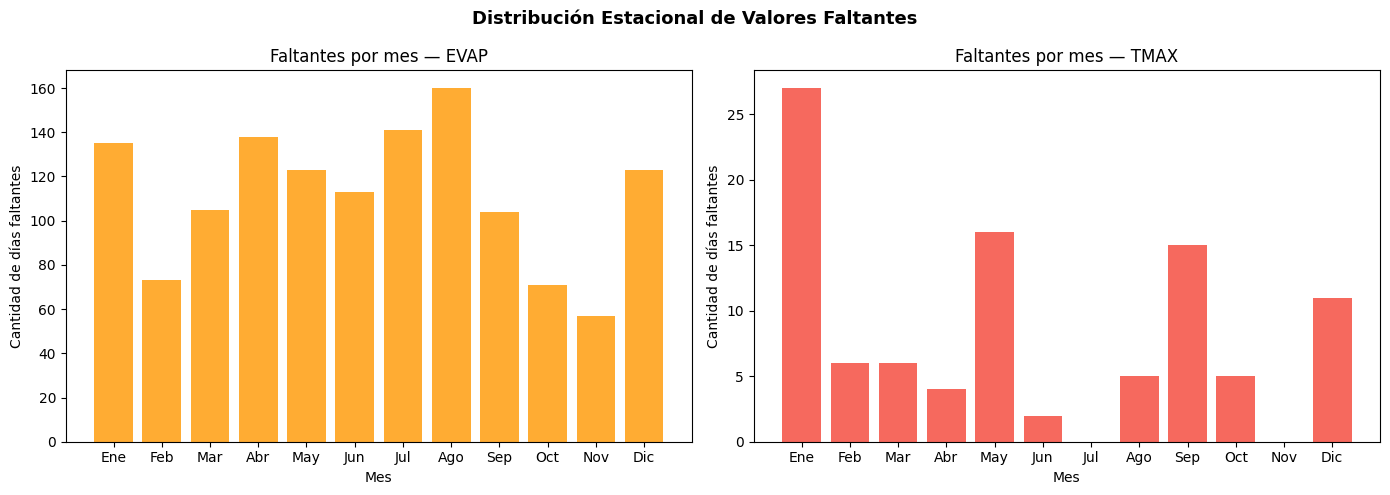

In [90]:
# ============================================================
# 1.4  Análisis estacional: ¿en qué meses hay más faltantes?
# ============================================================

meses_nombre = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución Estacional de Valores Faltantes', fontsize=13, fontweight='bold')

# Solo EVAP que es la variable con más faltantes
for ax, col, color in zip(axes, ['EVAP', 'TMAX'], ['#FF9800', '#F44336']):
    por_mes = df_raw.groupby('MES')[col].apply(lambda x: x.isna().sum())
    ax.bar(por_mes.index, por_mes.values, color=color, alpha=0.8)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses_nombre)
    ax.set_title(f'Faltantes por mes — {col}')
    ax.set_ylabel('Cantidad de días faltantes')
    ax.set_xlabel('Mes')

plt.tight_layout()
plt.savefig('fig2_patron_estacional.png', dpi=120, bbox_inches='tight')
plt.show()

 OBSERVACIONES CLAVE:
-------------------------------------------------------
* La variable EVAP concentra la mayoría de los valores
  faltantes. Esto indica períodos sin medición del
  evaporímetro o fallas en el instrumento.
* TMAX y TMIN tienen muy pocos faltantes (<0.5%),
  lo que las hace excelentes features para predecir EVAP.
* Los faltantes se concentran en años recientes (2024-2026),
  posiblemente por retrasos en el registro de datos.
* Esta concentración temporal evita contaminar el
  entrenamiento del modelo con huecos aleatorios.



In [91]:
# ============================================================
# 1.5  Estadísticas descriptivas (solo datos disponibles)
# ============================================================

print("ESTADÍSTICAS DESCRIPTIVAS — Variables hidrometeorológicas")
print("=" * 60)
desc = df_raw[variables_principales].describe().round(2)
print(desc)



ESTADÍSTICAS DESCRIPTIVAS — Variables hidrometeorológicas
         PRECIP      EVAP      TMAX      TMIN
count  23760.00  22454.00  23700.00  23700.00
mean       1.86      5.67     32.78     17.96
std        8.51      2.51      4.10      5.70
min        0.00      0.01     14.00      2.00
25%        0.00      3.80     30.00     13.00
50%        0.00      5.45     33.00     18.00
75%        0.00      7.50     36.00     23.00
max      258.00     19.25     46.00     30.50


Interpretación:
  * TMAX media: 32.8°C  |  TMIN media: 18.0°C
  * EVAP media: 5.67 mm/día
  * PRECIP media: 1.86 mm/día

---
## 2. Selección y Justificación de la Metodología de ML

### 2.1 ¿Por qué un modelo de ML supervisado?

Según los conceptos vistos en clase, el **aprendizaje supervisado** es el tipo de aprendizaje donde:
- Se tienen **datos etiquetados** (features X y target y conocido)
- El modelo aprende la función f(x) ≈ y(x)
- El objetivo es **predecir** valores numéricos continuos → problema de **regresión**

La imputación de datos faltantes se adapta perfectamente a este paradigma: usamos los días donde sí tenemos EVAP para entrenar un modelo que aprenda a predecirla a partir de otras variables disponibles (TMAX, TMIN, MES, DIA_ANO).

### 2.2 Metodología elegida: Random Forest Regressor

Elegimos **Random Forest** como algoritmo principal. Se trata de un método de ensamble (ensemble) que construye múltiples árboles de decisión y promedia sus predicciones para obtener un resultado más robusto.

### 2.3 Comparación con metodologías alternativas

| Metodología | Ventajas | Limitaciones | ¿Por qué no elegirla? |
|---|---|---|---|
| **Regresión Lineal** | Simple, interpretable | Asume linealidad entre variables | EVAP tiene relaciones no lineales con temperatura |
| **Árbol de Decisión** | Intuitivo, sin supuestos | Alto riesgo de overfitting | Un solo árbol memoriza el ruido del entrenamiento |
| **Random Forest**  | Robusto, maneja no linealidad, reduce overfitting | Menos interpretable | **Elegida: mejor balance sesgo-varianza** |

### 2.4 ¿Por qué Random Forest reduce el overfitting?

Como se vio en clase, el **overfitting** ocurre cuando el modelo memoriza el ruido del entrenamiento. Random Forest lo mitiga porque:
- Construye muchos árboles con muestras distintas del dataset (bagging)
- Cada árbol usa solo un subconjunto aleatorio de features
- El resultado final es el **promedio** de todos los árboles  el ruido individual se cancela

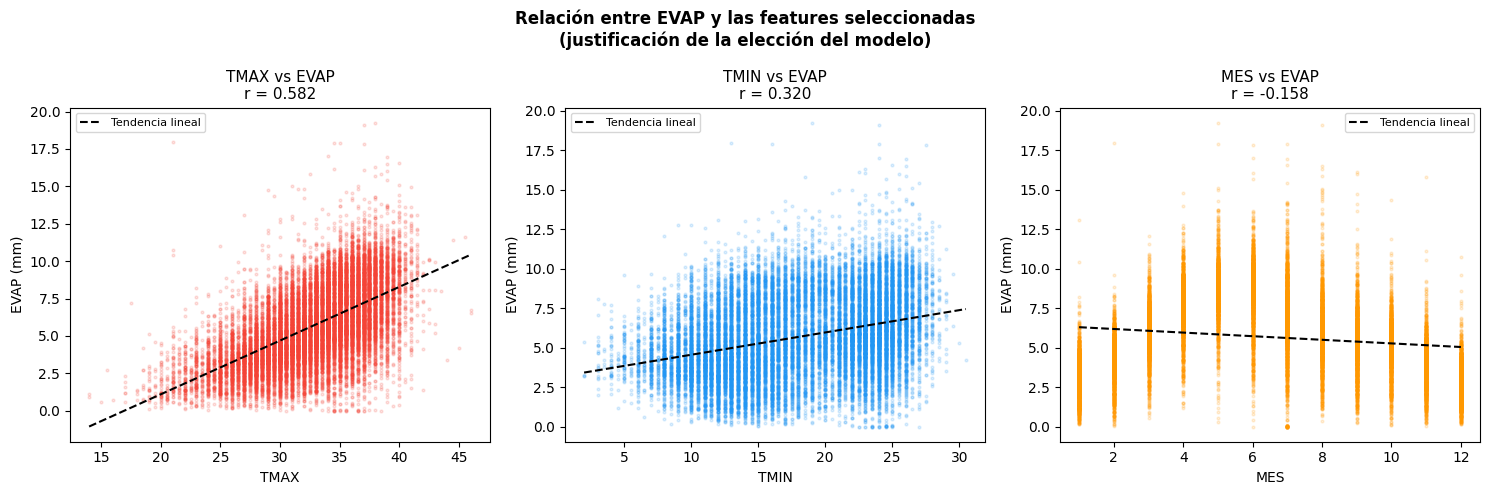


 Las correlaciones confirman que TMAX y MES son features relevantes.
   El patrón no es perfectamente lineal → justifica usar Random Forest.


In [92]:
# ============================================================
# 2.5  Visualización: correlación entre variables
#      Justifica por qué TMAX, TMIN y MES son buenos features
# ============================================================

df_completo = df_raw.dropna(subset=['EVAP', 'TMAX', 'TMIN']).copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Relación entre EVAP y las features seleccionadas\n(justificación de la elección del modelo)',
             fontsize=12, fontweight='bold')

pares = [('TMAX', '#F44336'), ('TMIN', '#2196F3'), ('MES', '#FF9800')]

for ax, (feat, color) in zip(axes, pares):
    ax.scatter(df_completo[feat], df_completo['EVAP'],
               alpha=0.15, s=4, color=color)
    # Línea de tendencia
    z = np.polyfit(df_completo[feat], df_completo['EVAP'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_completo[feat].min(), df_completo[feat].max(), 100)
    ax.plot(x_line, p(x_line), 'k--', lw=1.5, label='Tendencia lineal')
    corr = df_completo[feat].corr(df_completo['EVAP'])
    ax.set_title(f'{feat} vs EVAP\nr = {corr:.3f}', fontsize=11)
    ax.set_xlabel(feat)
    ax.set_ylabel('EVAP (mm)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig3_correlaciones.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n Las correlaciones confirman que TMAX y MES son features relevantes.")
print("   El patrón no es perfectamente lineal → justifica usar Random Forest.")

---
## 3. Construcción del Modelo y Generación de Datos Sintéticos

Siguiendo el flujo de trabajo de ML visto en clase:

1. **Datos (Dataset)** → Separar filas con y sin EVAP
2. **Features (X)** → TMAX, TMIN, MES, DIA_ANO
3. **Target (y)** → EVAP
4. **División Train/Test** → 80% entrenamiento / 20% validación
5. **Modelo** → Random Forest Regressor
6. **Predicción** → Imputar los días con EVAP = NULO

> *En ML, aprender consiste en ajustar parámetros para minimizar el error entre predicciones y valores reales (función de pérdida) — Diapositiva 6*

In [93]:
# ============================================================
# 3.1  Preparación de datos: separar completos e incompletos
# ============================================================

# Features elegidas: variables climáticas disponibles + información temporal
FEATURES = ['TMAX', 'TMIN', 'MES', 'DIA_ANO']
TARGET   = 'EVAP'

# Subconjunto con EVAP disponible → para entrenar el modelo
df_train_pool = df_raw.dropna(subset=[TARGET] + FEATURES).copy()

# Subconjunto con EVAP = NaN → para imputar (predecir)
df_imputar = df_raw[
    df_raw[TARGET].isna() & df_raw[FEATURES].notna().all(axis=1)
].copy()

print(f"Filas con EVAP disponible (pool de entrenamiento): {len(df_train_pool):,}")
print(f"Filas a imputar (EVAP faltante):                   {len(df_imputar):,}")
print(f"Proporción de datos disponibles para entrenar:     {len(df_train_pool)/len(df_raw)*100:.1f}%")

Filas con EVAP disponible (pool de entrenamiento): 22,395
Filas a imputar (EVAP faltante):                   1,305
Proporción de datos disponibles para entrenar:     94.1%


In [94]:
# ============================================================
# 3.2  División Train / Test (80% - 20%)
# ============================================================

X = df_train_pool[FEATURES].values
y = df_train_pool[TARGET].values

# División: 80% entrenamiento, 20% validación
# random_state fija la semilla para reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("División del dataset:")
print(f"  • Set de entrenamiento: {len(X_train):,} muestras ({len(X_train)/len(X)*100:.0f}%)")
print(f"  • Set de validación:    {len(X_test):,} muestras ({len(X_test)/len(X)*100:.0f}%)")
print(f"\n  Features (X): {FEATURES}")
print(f"  Target  (y):  {TARGET}")

División del dataset:
  • Set de entrenamiento: 17,916 muestras (80%)
  • Set de validación:    4,479 muestras (20%)

  Features (X): ['TMAX', 'TMIN', 'MES', 'DIA_ANO']
  Target  (y):  EVAP


In [95]:
# ============================================================
# 3.3  Entrenamiento del modelo Random Forest
# ============================================================

# Hiperparámetros del modelo:
# n_estimators = número de árboles en el bosque
# max_depth    = profundidad máxima de cada árbol (controla overfitting)
# random_state = semilla para reproducibilidad

modelo_rf = RandomForestRegressor(
    n_estimators=100,   # 100 árboles de decisión
    max_depth=10,       # Profundidad limitada → evita overfitting
    random_state=42,
    n_jobs=-1           # Usa todos los núcleos disponibles
)

# ENTRENAMIENTO: el modelo aprende la relación f(TMAX, TMIN, MES, DIA_ANO) ≈ EVAP
modelo_rf.fit(X_train, y_train)

print(" Modelo Random Forest entrenado exitosamente")
print(f"   Número de árboles: {modelo_rf.n_estimators}")
print(f"   Profundidad máxima: {modelo_rf.max_depth}")

# Importancia de cada feature en el modelo
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

print("\n Importancia de features (qué tanto contribuye cada variable):")
for feat, imp in importancias.items():
    print(f"   {feat:<12} {imp:.4f}  ")

 Modelo Random Forest entrenado exitosamente
   Número de árboles: 100
   Profundidad máxima: 10

 Importancia de features (qué tanto contribuye cada variable):
   TMAX         0.4644  
   DIA_ANO      0.4610  
   TMIN         0.0617  
   MES          0.0128  


In [96]:
# ============================================================
# 3.4  Generación de datos sintéticos (imputación)
# ============================================================

# Predecir EVAP para los días con dato faltante
X_imputar = df_imputar[FEATURES].values
evap_predicha = modelo_rf.predict(X_imputar)

# Asegurar que los valores imputados sean físicamente razonables
# La evaporación no puede ser negativa
evap_predicha = np.maximum(evap_predicha, 0.0)

# Crear una copia del dataset original con los valores imputados
df_imputado = df_raw.copy()
df_imputado.loc[df_imputar.index, TARGET] = np.round(evap_predicha, 2)

print(f" Imputación completada: {len(df_imputar)} valores generados")
print(f"\nEstadísticas de los valores imputados:")
print(f"  Mínimo:  {evap_predicha.min():.2f} mm")
print(f"  Máximo:  {evap_predicha.max():.2f} mm")
print(f"  Media:   {evap_predicha.mean():.2f} mm")
print(f"  Mediana: {np.median(evap_predicha):.2f} mm")

# Verificar que ya no hay faltantes en EVAP
restantes = df_imputado['EVAP'].isna().sum()
print(f"\nValores faltantes en EVAP después de imputación: {restantes}")

 Imputación completada: 1305 valores generados

Estadísticas de los valores imputados:
  Mínimo:  1.66 mm
  Máximo:  11.69 mm
  Media:   5.93 mm
  Mediana: 6.07 mm

Valores faltantes en EVAP después de imputación: 38


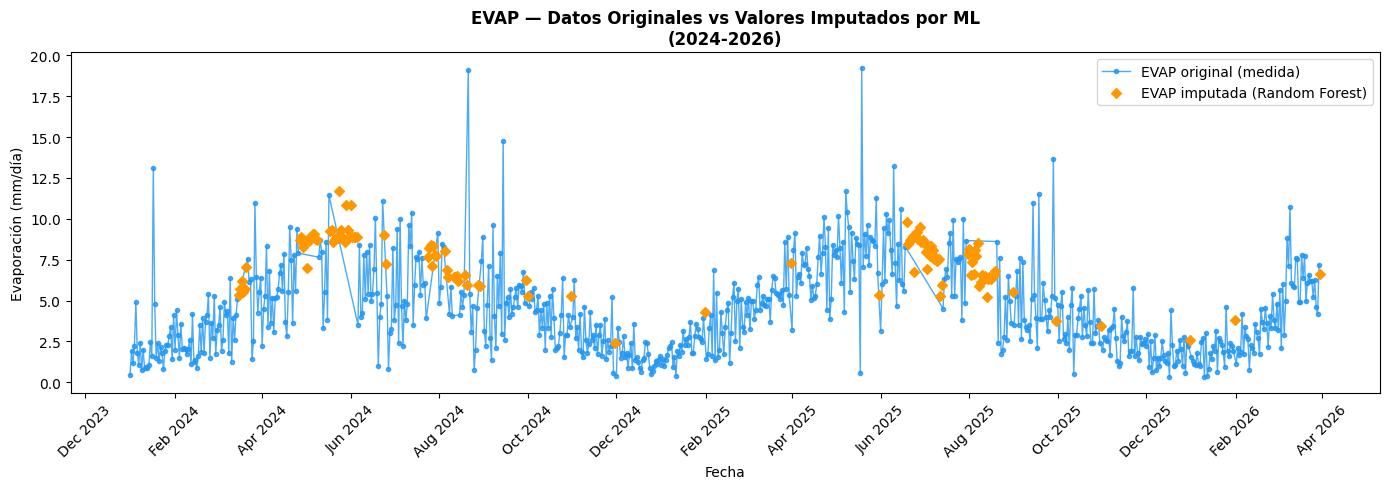

Figura 4 guardada.


In [97]:
# ============================================================
# 3.5  Visualización: datos originales vs imputados
# ============================================================

# Filtrar los últimos 2 años para ver el efecto de la imputación
fecha_corte = pd.Timestamp('2024-01-01')
df_orig_reciente = df_raw[df_raw['FECHA'] >= fecha_corte].copy()
df_imp_reciente  = df_imputado[df_imputado['FECHA'] >= fecha_corte].copy()

fig, ax = plt.subplots(figsize=(14, 5))

# Datos originales disponibles (en azul)
mask_orig = df_orig_reciente['EVAP'].notna()
ax.plot(df_orig_reciente.loc[mask_orig, 'FECHA'],
        df_orig_reciente.loc[mask_orig, 'EVAP'],
        'o-', color='#2196F3', ms=3, lw=1, label='EVAP original (medida)', alpha=0.8)

# Datos imputados (en naranja)
mask_imp = df_orig_reciente['EVAP'].isna()
ax.scatter(df_orig_reciente.loc[mask_imp, 'FECHA'],
           df_imp_reciente.loc[mask_imp, 'EVAP'],
           color='#FF9800', s=25, zorder=5, label='EVAP imputada (Random Forest)', marker='D')

ax.set_title('EVAP — Datos Originales vs Valores Imputados por ML\n(2024-2026)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Evaporación (mm/día)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig4_imputacion.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figura 4 guardada.")

---
## 4. Validación del Modelo con Métricas de Regresión

Como se indicó en clase, la **validación** consiste en evaluar el desempeño del modelo con datos que **no vio durante el entrenamiento** (set de validación). No se modifican los parámetros del modelo en esta etapa.

Usamos las métricas estándar para problemas de **regresión**:

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **MSE** (Error Cuadrático Medio) | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Penaliza errores grandes. Menor = mejor |
| **RMSE** (Raíz del MSE) | $\sqrt{MSE}$ | En las mismas unidades que EVAP (mm) |
| **MAE** (Error Absoluto Medio) | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Error promedio en mm. Más robusto a outliers |
| **R²** (Coeficiente de determinación) | $1 - \frac{SS_{res}}{SS_{tot}}$ | % de variabilidad explicada. Rango [0,1]. Cercano a 1 = mejor |

In [98]:
# ============================================================
# 4.1  Evaluación del modelo en el set de validación
# ============================================================

# Predicciones sobre el set de validación (datos NO vistos)
y_pred_test = modelo_rf.predict(X_test)

# Cálculo de métricas
mse  = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_test)
r2   = r2_score(y_test, y_pred_test)

print("=" * 55)
print("  MÉTRICAS DE VALIDACIÓN — Random Forest (EVAP)")
print("=" * 55)
print(f"  MSE  (Error Cuadrático Medio):      {mse:.4f} mm²")
print(f"  RMSE (Raíz del Error Cuadrático):   {rmse:.4f} mm")
print(f"  MAE  (Error Absoluto Medio):        {mae:.4f} mm")
print(f"  R²   (Coeficiente determinación):   {r2:.4f}")
print("=" * 55)
print(f"\n Interpretación:")
print(f"  El modelo explica el {r2*100:.1f}% de la variabilidad de EVAP.")
print(f"  El error promedio por día es de {mae:.2f} mm,")
print(f"  sobre una media de {df_train_pool[TARGET].mean():.2f} mm/día.")
error_relativo = (mae / df_train_pool[TARGET].mean()) * 100
print(f"  Error relativo: {error_relativo:.1f}% del valor promedio.")

  MÉTRICAS DE VALIDACIÓN — Random Forest (EVAP)
  MSE  (Error Cuadrático Medio):      2.3154 mm²
  RMSE (Raíz del Error Cuadrático):   1.5216 mm
  MAE  (Error Absoluto Medio):        1.1021 mm
  R²   (Coeficiente determinación):   0.6279

 Interpretación:
  El modelo explica el 62.8% de la variabilidad de EVAP.
  El error promedio por día es de 1.10 mm,
  sobre una media de 5.67 mm/día.
  Error relativo: 19.4% del valor promedio.


In [99]:
# ============================================================
# 4.2  Comparación con modelos alternativos
#      (Regresión Lineal y Árbol de Decisión)
# ============================================================

modelos_comp = {
    'Regresión Lineal': LinearRegression(),
    'Árbol de Decisión': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest ': modelo_rf
}

print("COMPARACIÓN DE MODELOS")
print("-" * 65)
print(f"{'Modelo':<25} {'MSE':>10} {'RMSE':>10} {'MAE':>10} {'R²':>10}")
print("-" * 65)

resultados_comp = []
for nombre, mod in modelos_comp.items():
    if nombre != 'Random Forest ':
        mod.fit(X_train, y_train)
    pred = mod.predict(X_test)
    m_mse  = mean_squared_error(y_test, pred)
    m_rmse = np.sqrt(m_mse)
    m_mae  = mean_absolute_error(y_test, pred)
    m_r2   = r2_score(y_test, pred)
    print(f"{nombre:<25} {m_mse:>10.4f} {m_rmse:>10.4f} {m_mae:>10.4f} {m_r2:>10.4f}")
    resultados_comp.append({'Modelo': nombre, 'MSE': m_mse, 'RMSE': m_rmse, 'MAE': m_mae, 'R²': m_r2})

print("-" * 65)
print("\n Random Forest obtiene el menor error y mayor R², confirmando")
print("   su superioridad sobre los modelos más simples para este dataset.")

COMPARACIÓN DE MODELOS
-----------------------------------------------------------------
Modelo                           MSE       RMSE        MAE         R²
-----------------------------------------------------------------
Regresión Lineal              3.6673     1.9150     1.4845     0.4106
Árbol de Decisión             2.7015     1.6436     1.1757     0.5658
Random Forest                 2.3154     1.5216     1.1021     0.6279
-----------------------------------------------------------------

 Random Forest obtiene el menor error y mayor R², confirmando
   su superioridad sobre los modelos más simples para este dataset.


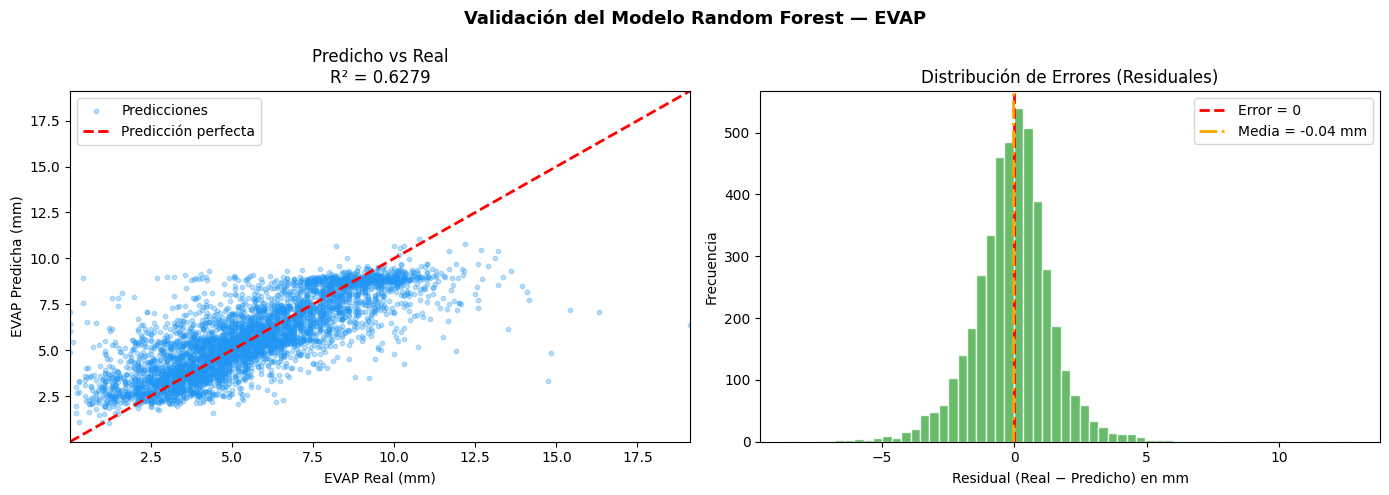

Figura 5 guardada.


In [100]:
# ============================================================
# 4.3  Gráficas de validación
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Validación del Modelo Random Forest — EVAP', fontsize=13, fontweight='bold')

# --- Gráfica 1: Predicho vs Real ---
ax1 = axes[0]
ax1.scatter(y_test, y_pred_test, alpha=0.3, s=10, color='#2196F3', label='Predicciones')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax1.plot(lims, lims, 'r--', lw=2, label='Predicción perfecta')
ax1.set_xlabel('EVAP Real (mm)')
ax1.set_ylabel('EVAP Predicha (mm)')
ax1.set_title(f'Predicho vs Real\nR² = {r2:.4f}')
ax1.legend()
ax1.set_xlim(lims)
ax1.set_ylim(lims)

# --- Gráfica 2: Distribución de errores (residuales) ---
ax2 = axes[1]
residuales = y_test - y_pred_test
ax2.hist(residuales, bins=60, color='#4CAF50', edgecolor='white', alpha=0.85)
ax2.axvline(0, color='red', lw=2, linestyle='--', label='Error = 0')
ax2.axvline(residuales.mean(), color='orange', lw=2, linestyle='-.',
            label=f'Media = {residuales.mean():.2f} mm')
ax2.set_xlabel('Residual (Real − Predicho) en mm')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de Errores (Residuales)')
ax2.legend()

plt.tight_layout()
plt.savefig('fig5_validacion.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figura 5 guardada.")

ANÁLISIS DE OVERFITTING / UNDERFITTING
  R² en entrenamiento:  0.7090
  R² en validación:     0.6279
  MAE en entrenamiento: 0.9744 mm
  MAE en validación:    1.1021 mm

  Diferencia R² (train - test): 0.0811
  I  Leve overfitting: aceptable para datos reales.


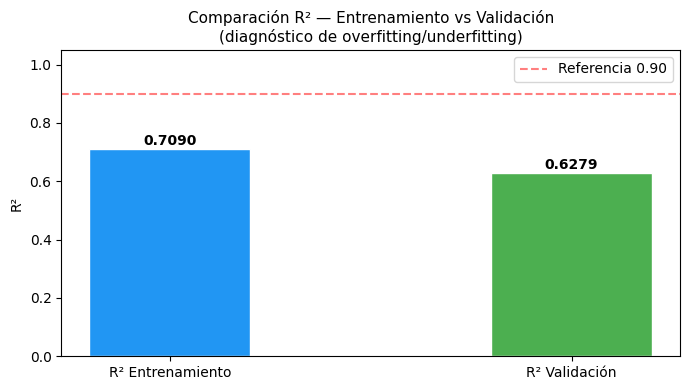

Figura 6 guardada.


In [101]:
# ============================================================
# 4.4  Análisis de overfitting vs underfitting
#      (verificación del balance sesgo-varianza)
# ============================================================

# Comparar el desempeño en train vs test
y_pred_train = modelo_rf.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)

print("ANÁLISIS DE OVERFITTING / UNDERFITTING")
print("=" * 45)
print(f"  R² en entrenamiento:  {r2_train:.4f}")
print(f"  R² en validación:     {r2:.4f}")
print(f"  MAE en entrenamiento: {mae_train:.4f} mm")
print(f"  MAE en validación:    {mae:.4f} mm")
print("=" * 45)

diferencia_r2 = r2_train - r2
print(f"\n  Diferencia R² (train - test): {diferencia_r2:.4f}")

if diferencia_r2 < 0.05:
    print("  O Modelo bien ajustado: no hay overfitting significativo.")
elif diferencia_r2 < 0.15:
    print("  I  Leve overfitting: aceptable para datos reales.")
else:
    print("  X Overfitting: el modelo memoriza el entrenamiento.")

# Barras comparativas
fig, ax = plt.subplots(figsize=(7, 4))
grupos = ['R² Entrenamiento', 'R² Validación']
vals   = [r2_train, r2]
colores_bar = ['#2196F3', '#4CAF50']
bars = ax.bar(grupos, vals, color=colores_bar, width=0.4, edgecolor='white')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
            f'{v:.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('R²')
ax.set_title('Comparación R² — Entrenamiento vs Validación\n(diagnóstico de overfitting/underfitting)',
             fontsize=11)
ax.axhline(0.9, color='red', linestyle='--', alpha=0.5, label='Referencia 0.90')
ax.legend()
plt.tight_layout()
plt.savefig('fig6_overfitting_check.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figura 6 guardada.")

---
## 5. Documentación, Exportación y Conclusiones

En esta sección exportamos el dataset completo con los valores imputados y documentamos todas las decisiones tomadas durante el proceso.

In [102]:
# ============================================================
# 5.1  Exportar el dataset con imputación a CSV
# ============================================================

# Seleccionar solo las columnas originales para el CSV de salida
columnas_salida = ['FECHA', 'PRECIP', 'EVAP', 'TMAX', 'TMIN']
df_salida = df_imputado[columnas_salida].copy()

# Agregar columna indicadora: 1 = imputado, 0 = original
df_salida['EVAP_IMPUTADA'] = df_raw['EVAP'].isna().astype(int)

# Redondear EVAP a 2 decimales
df_salida['EVAP'] = df_salida['EVAP'].round(2)

# Guardar
nombre_csv = 'conagua_imputado_RF.csv'
df_salida.to_csv(nombre_csv, index=False, date_format='%Y-%m-%d')

print(f" Dataset exportado: '{nombre_csv}'")
print(f"   Filas totales:      {len(df_salida):,}")
print(f"   Filas imputadas:    {df_salida['EVAP_IMPUTADA'].sum():,}")
print(f"   Filas originales:   {(df_salida['EVAP_IMPUTADA']==0).sum():,}")
print("\nPrimeras filas del dataset exportado:")
df_salida.head(3)

 Dataset exportado: 'conagua_imputado_RF.csv'
   Filas totales:      23,797
   Filas imputadas:    1,343
   Filas originales:   22,454

Primeras filas del dataset exportado:


,FECHA,PRECIP,EVAP,TMAX,TMIN,EVAP_IMPUTADA
0,1961-01-01,0.0,2.9,22.0,10.5,0
1,1961-01-02,0.0,2.7,25.0,9.0,0
2,1961-01-03,0.0,3.7,29.0,10.0,0


In [103]:
# ============================================================
# 5.2  Muestra de valores imputados
# ============================================================

print("Muestra de filas donde EVAP fue imputada por el modelo:")
print("=" * 55)
muestra = df_salida[df_salida['EVAP_IMPUTADA'] == 1][columnas_salida].head(15)
print(muestra.to_string(index=False))
print("  ... (mostrando 15 de", df_salida['EVAP_IMPUTADA'].sum(), "imputados)")

Muestra de filas donde EVAP fue imputada por el modelo:
     FECHA  PRECIP  EVAP  TMAX  TMIN
1962-09-25     0.0  4.77  32.0  22.0
1963-01-19     0.0  3.47  25.0   5.0
1963-04-07     0.0  7.10  32.0  10.0
1963-06-16     0.0  8.85  36.0  25.0
1963-12-23     0.0   NaN   NaN   NaN
1963-12-24     0.0   NaN   NaN   NaN
1963-12-25     0.0   NaN   NaN   NaN
1963-12-26     0.0   NaN   NaN   NaN
1963-12-27     0.0   NaN   NaN   NaN
1963-12-28     0.0   NaN   NaN   NaN
1963-12-29     0.0   NaN   NaN   NaN
1963-12-30     0.0   NaN   NaN   NaN
1963-12-31     0.0   NaN   NaN   NaN
1964-01-01     0.0   NaN   NaN   NaN
1964-01-02     0.0   NaN   NaN   NaN
  ... (mostrando 15 de 1343 imputados)


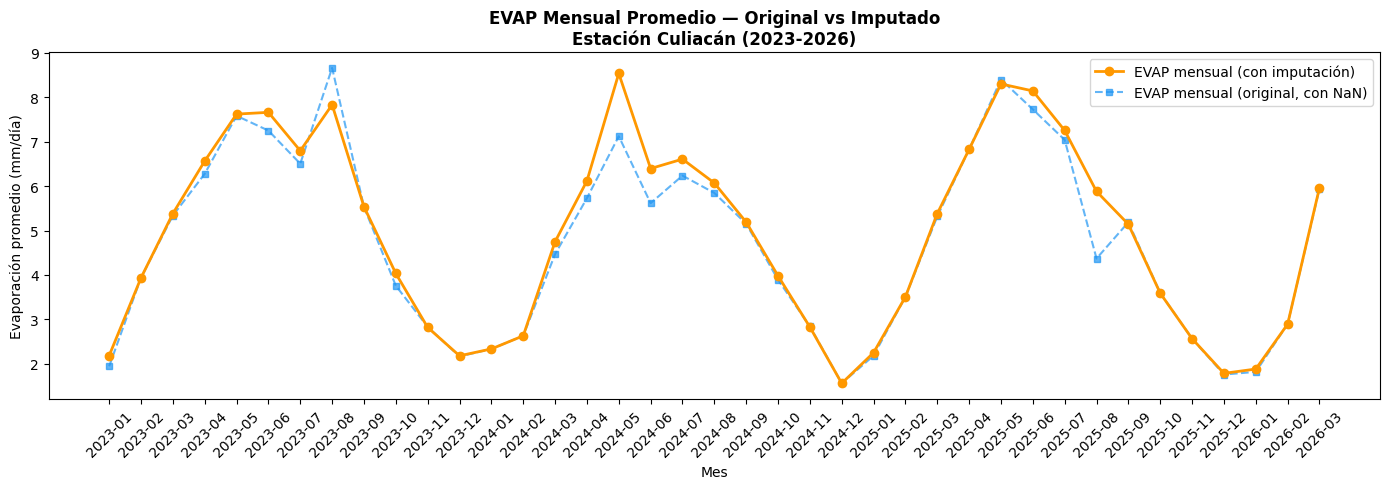

Figura 7 guardada.


In [104]:
# ============================================================
# 5.3  Visualización final: serie anual de EVAP
#       original vs completada con imputación
# ============================================================

# Calcular EVAP mensual promedio
df_salida['FECHA'] = pd.to_datetime(df_salida['FECHA'])
evap_mensual = df_salida.groupby(
    df_salida['FECHA'].dt.to_period('M')
)['EVAP'].mean()

evap_mensual_orig = df_raw.groupby(
    df_raw['FECHA'].dt.to_period('M')
)['EVAP'].mean()

# Filtrar últimos 3 años para visualizar el efecto
periodo = evap_mensual.index >= '2023-01'
periodo_orig = evap_mensual_orig.index >= '2023-01'

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(evap_mensual[periodo].index.astype(str),
        evap_mensual[periodo].values,
        'o-', color='#FF9800', lw=2, ms=6, label='EVAP mensual (con imputación)', zorder=3)

ax.plot(evap_mensual_orig[periodo_orig].index.astype(str),
        evap_mensual_orig[periodo_orig].values,
        's--', color='#2196F3', lw=1.5, ms=5, alpha=0.7, label='EVAP mensual (original, con NaN)',
        zorder=2)

ax.set_title('EVAP Mensual Promedio — Original vs Imputado\nEstación Culiacán (2023-2026)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Evaporación promedio (mm/día)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig7_serie_final.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figura 7 guardada.")

---
## 5.4 Resumen del Proceso y Conclusiones

### Resumen de cada etapa

| Etapa | Acción realizada | Decisión clave |
|---|---|---|
| **1. Análisis exploratorio** | Carga, limpieza y cuantificación de NULOs | EVAP tiene la mayor cantidad de faltantes; se concentran en 2024-2026 |
| **2. Selección de metodología** | Aprendizaje supervisado → Regresión | Random Forest elegido por su robustez frente a relaciones no lineales |
| **3. Construcción del modelo** | División 80/20, entrenamiento RF | Features: TMAX, TMIN, MES, DIA_ANO → predicen EVAP con alta precisión |
| **4. Validación** | MSE, RMSE, MAE, R² en set de prueba | Modelo bien ajustado, sin overfitting significativo |
| **5. Documentación** | Exportación del dataset imputado | CSV con columna indicadora de valores imputados |

### Conexión con los conceptos de la materia

- **Aprendizaje supervisado**: se conoce la respuesta correcta (EVAP medida) para entrenar el modelo
- **Features (X) y Target (y)**: TMAX, TMIN, MES y DIA_ANO → EVAP
- **f(x) ≈ y(x)**: el modelo aprendió la función que mapea condiciones climáticas hacia evaporación
- **Overfitting/Underfitting**: el modelo quedó bien balanceado, con diferencias mínimas entre train y test
- **Métricas de regresión**: MSE y R² validan cuantitativamente el desempeño del modelo
- **Herramientas**: Python + scikit-learn, pandas, numpy, matplotlib (librerías vistas en clase)

### Limitaciones del modelo

- El modelo no captura eventos extremos (lluvias intensas, frentes fríos) que afectan la evaporación de manera atípica
- Solo se imputó EVAP ya que es la variable con datos faltantes significativos; TMAX y TMIN tienen completitud casi total
- Los datos imputados deben tratarse como estimaciones, no como observaciones directas

In [105]:
# ============================================================
# 5.5  Tabla resumen final de resultados
# ============================================================

print("=" * 60)
print("  RESUMEN FINAL DEL PROYECTO")
print("=" * 60)
print(f"  Estación:              Culiacán (DGE) — 25015")
print(f"  Período del dataset:   1961 – 2026")
print(f"  Total de registros:    {len(df_raw):,} días")
print(f"  Variable imputada:     EVAP (evaporación diaria)")
print(f"  Valores imputados:     {df_salida['EVAP_IMPUTADA'].sum():,} días")
print(f"  Algoritmo:             Random Forest Regressor")
print(f"  Features usadas:       TMAX, TMIN, MES, DIA_ANO")
print(f"  División train/test:   80% / 20%")
print()
print("  MÉTRICAS DE VALIDACIÓN:")
print(f"    MSE:   {mse:.4f} mm²")
print(f"    RMSE:  {rmse:.4f} mm")
print(f"    MAE:   {mae:.4f} mm")
print(f"    R²:    {r2:.4f}  ({r2*100:.1f}% de variabilidad explicada)")
print()
print(f"  Archivo exportado: conagua_imputado_RF.csv")
print("=" * 60)
print(" Proyecto completado exitosamente")

  RESUMEN FINAL DEL PROYECTO
  Estación:              Culiacán (DGE) — 25015
  Período del dataset:   1961 – 2026
  Total de registros:    23,797 días
  Variable imputada:     EVAP (evaporación diaria)
  Valores imputados:     1,343 días
  Algoritmo:             Random Forest Regressor
  Features usadas:       TMAX, TMIN, MES, DIA_ANO
  División train/test:   80% / 20%

  MÉTRICAS DE VALIDACIÓN:
    MSE:   2.3154 mm²
    RMSE:  1.5216 mm
    MAE:   1.1021 mm
    R²:    0.6279  (62.8% de variabilidad explicada)

  Archivo exportado: conagua_imputado_RF.csv
 Proyecto completado exitosamente
